# ML_inflammation: Infection/Inflammation Prediction

**Purpose:** Build and evaluate machine learning models to predict `infection_inflammation` (binary 0/1) from NHANES survey and lab features.

**Target:** `infection_inflammation` — 1 = infection/inflammation present, 0 = not present. Acute infection rows (NaN) are excluded.

**Approach:** Logistic Regression (L1/L2), Random Forest, XGBoost, and ensemble stacking. Threshold set at 0.3 for screening (prioritize recall).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings, joblib, json
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score, accuracy_score, f1_score, roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from xgboost import XGBClassifier
from scipy.stats import mannwhitneyu
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 100

## Section 1: Data Loading & Feature Map

In [2]:
df_raw = pd.read_csv('../data/processed/nhanes_merged_adults_final.csv', low_memory=False)

FEATURE_MAP = {
    # LAB
    'total_cholesterol':      'LBXTC_total_cholesterol_mg_dl',
    'ldl_cholesterol':        'LBDLDL_ldl_cholesterol_friedewald_mg_dl',
    'hdl_cholesterol':        'LBDHDD_direct_hdl_cholesterol_mg_dl',
    'triglycerides':          'LBXTR_triglyceride_mg_dl',
    'serum_glucose':          'LBXSGL_glucose_refrigerated_serum_mg_dl',
    'fasting_glucose':        'LBXGLU_fasting_glucose_mg_dl',
    'creatinine':             'LBXSCR_creatinine_refrigerated_serum_mg_dl',
    'sbp_1': 'sbp_1', 'sbp_2': 'sbp_2', 'sbp_3': 'sbp_3',
    'dbp_1': 'dbp_1', 'dbp_2': 'dbp_2', 'dbp_3': 'dbp_3',
    'pulse_1': 'pulse_1', 'pulse_2': 'pulse_2', 'pulse_3': 'pulse_3',
    'bmi':                    'bmi',
    'calcium':                'LBXSCA_total_calcium_mg_dl',
    'age_years':              'age_years',
    # QUEST
    'smoking_now':            'smq040___do_you_now_smoke_cigarettes?',
    'cigarettes_per_day':     'smd650___avg_#_cigarettes/day_during_past_30_days',
    'avg_drinks_per_day':     'alq130___avg_#_alcoholic_drinks/day___past_12_mos',
    'ever_heavy_drinker':     'alq151___ever_have_4/5_or_more_drinks_every_day?',
    'sedentary_minutes':      'pad680___minutes_sedentary_activity',
    'vigorous_exercise':      'paq650___vigorous_recreational_activities',
    'moderate_exercise':      'paq665___moderate_recreational_activities',
    'sleep_hours_weekdays':   'sld012___sleep_hours___weekdays_or_workdays',
    'told_dr_trouble_sleeping': 'slq050___ever_told_doctor_had_trouble_sleeping?',
    'work_schedule':          'ocq670___overall_work_schedule_past_3_months',
    'hours_worked_per_week':  'ocq180___hours_worked_last_week_in_total_all_jobs',
    'diabetes':               'diq010___doctor_told_you_have_diabetes',
    'doctor_said_overweight': 'mcq080___doctor_ever_said_you_were_overweight',
    'liver_condition':        'mcq160l___ever_told_you_had_any_liver_condition',
    'kidney_disease':         'kiq022___ever_told_you_had_weak/failing_kidneys?',
    'regular_periods':        'rhq031___had_regular_periods_in_past_12_months',
    'general_health_condition': 'huq010___general_health_condition',
    'waist_cm':               'waist_cm',
    'gender':                 'gender',
    # TARGET
    'infection_inflammation': 'infection_inflammation',
}

_valid = {k: v for k, v in FEATURE_MAP.items() if v in df_raw.columns}
df = df_raw[list(_valid.values())].copy()
df.columns = list(_valid.keys())

# Average repeated BP/pulse readings
for pfx in ['sbp', 'dbp', 'pulse']:
    cs = [c for c in df.columns if c.startswith(f'{pfx}_')]
    if cs:
        df[f'{pfx}_mean'] = df[cs].mean(axis=1)
        df.drop(columns=cs, inplace=True)

TARGET = 'infection_inflammation'
df = df.dropna(subset=[TARGET])
df[TARGET] = df[TARGET].astype(int)

# Encode object/category columns — wrap codes in pd.Series to support .replace()
for col in df.select_dtypes(include=['object', 'category']).columns:
    if col != TARGET:
        codes = pd.Categorical(df[col]).codes
        df[col] = pd.Series(codes.astype(float), index=df.index).replace(-1, np.nan)

print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Features: {df.shape[1]-1}')
print(f'Target positive rate: {df[TARGET].mean()*100:.1f}%')
df.head(3)

Dataset: 7,428 rows x 33 columns
Features: 32
Target positive rate: 32.4%


,total_cholesterol,ldl_cholesterol,hdl_cholesterol,triglycerides,serum_glucose,fasting_glucose,creatinine,bmi,calcium,age_years,...,liver_condition,kidney_disease,regular_periods,general_health_condition,waist_cm,gender,infection_inflammation,sbp_mean,dbp_mean,pulse_mean
0,195.0,NaN,56.0,NaN,83.0,NaN,0.63,37.8,8.8,29.0,...,2.0,2.0,1.0,3.0,117.9,0.0,0,99.0,54.333333,66.666667
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,...,2.0,2.0,NaN,1.0,NaN,0.0,0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,...,NaN,NaN,NaN,3.0,NaN,0.0,0,NaN,NaN,NaN


## Section 2: Exploratory Data Analysis

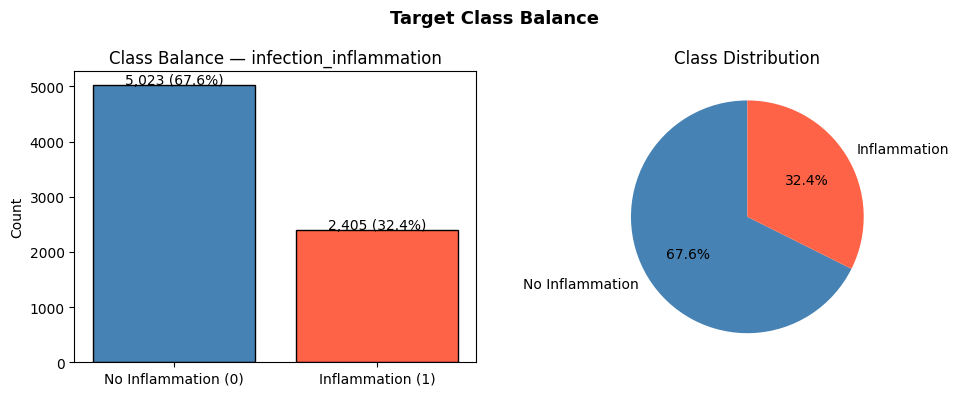

Class 0: 5,023 (67.6%)
Class 1: 2,405 (32.4%)
Imbalance ratio: 2.09:1


In [3]:
# Class balance
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
counts = df[TARGET].value_counts().sort_index()
ax[0].bar(['No Inflammation (0)', 'Inflammation (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')
ax[0].set_title('Class Balance — infection_inflammation')
ax[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 20, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

ax[1].pie(counts.values, labels=['No Inflammation', 'Inflammation'], autopct='%1.1f%%',
          colors=['steelblue', 'tomato'], startangle=90)
ax[1].set_title('Class Distribution')
plt.suptitle('Target Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Class 0: {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
print(f'Class 1: {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')
print(f'Imbalance ratio: {counts[0]/counts[1]:.2f}:1')

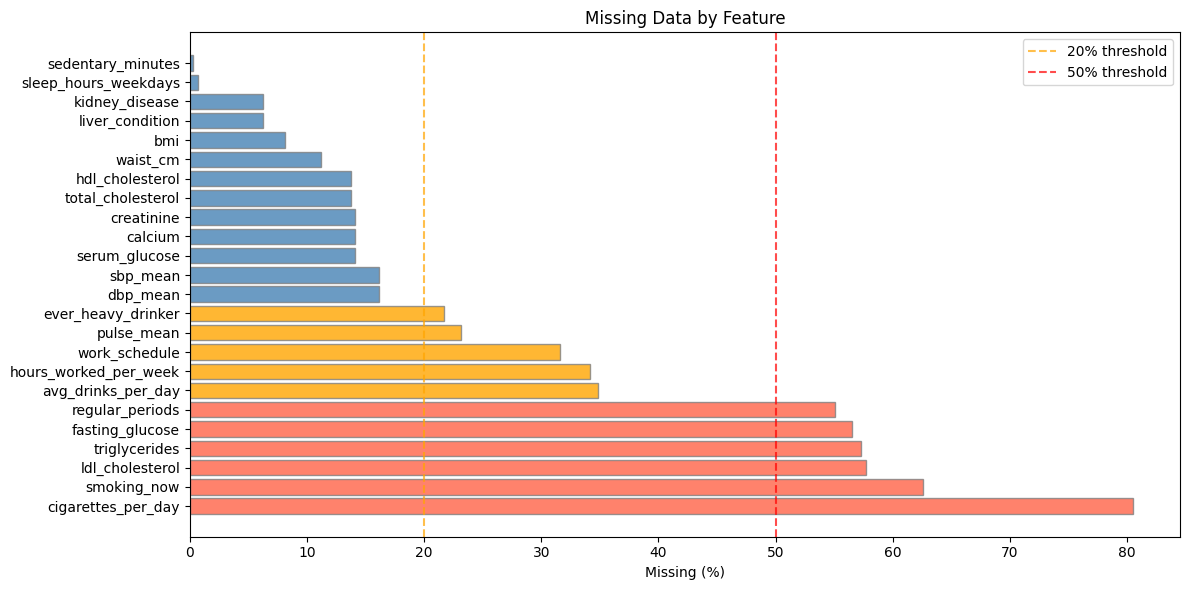

Features with any missing: 24/32
Features >50% missing: 6
Features >20% missing: 11


In [4]:
# Missing data bar chart
feat_cols = [c for c in df.columns if c != TARGET]
miss_pct = df[feat_cols].isnull().mean().sort_values(ascending=False)
miss_pct_nonzero = miss_pct[miss_pct > 0]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['tomato' if v > 0.5 else 'orange' if v > 0.2 else 'steelblue' for v in miss_pct_nonzero.values]
ax.barh(miss_pct_nonzero.index, miss_pct_nonzero.values * 100, color=colors, edgecolor='gray', alpha=0.8)
ax.axvline(20, color='orange', linestyle='--', alpha=0.7, label='20% threshold')
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Feature')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Features with any missing: {len(miss_pct_nonzero)}/{len(feat_cols)}')
print(f'Features >50% missing: {(miss_pct > 0.5).sum()}')
print(f'Features >20% missing: {(miss_pct > 0.2).sum()}')

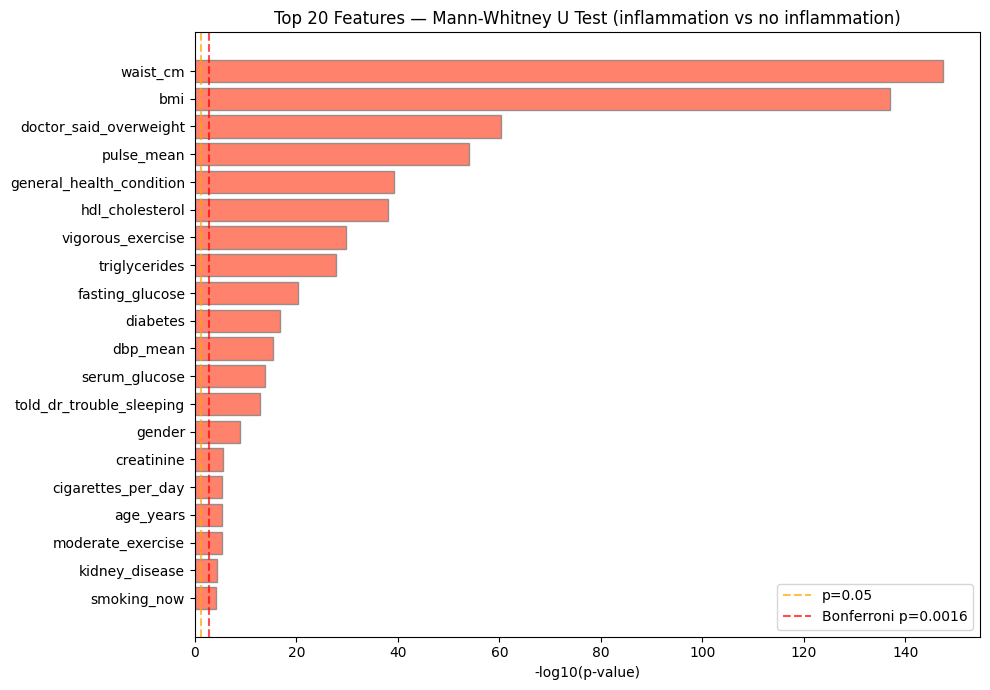

Features with p < 0.05: 27
Features with Bonferroni-corrected p < 0.05: 23

Top 10 most significant features:
waist_cm                    4.583018e-148
bmi                         1.124655e-137
doctor_said_overweight       4.277960e-61
pulse_mean                   9.327786e-55
general_health_condition     6.478520e-40
hdl_cholesterol              9.416303e-39
vigorous_exercise            1.328479e-30
triglycerides                1.328120e-28
fasting_glucose              4.281981e-21
diabetes                     1.361460e-17


In [5]:
# Feature distributions by target (Mann-Whitney U)
numeric_feats = [c for c in feat_cols if df[c].dtype in [np.float64, np.int64, float, int]]
pvals = {}
for col in numeric_feats:
    g0 = df.loc[df[TARGET]==0, col].dropna()
    g1 = df.loc[df[TARGET]==1, col].dropna()
    if len(g0) > 10 and len(g1) > 10:
        stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
        pvals[col] = p

pval_series = pd.Series(pvals).sort_values()
top20 = pval_series.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
log10p = -np.log10(top20.values + 1e-300)
colors = ['tomato' if p < 0.05/len(pvals) else 'orange' if p < 0.05 else 'steelblue' for p in top20.values]
ax.barh(top20.index[::-1], log10p[::-1], color=colors[::-1], edgecolor='gray', alpha=0.8)
ax.axvline(-np.log10(0.05), color='orange', linestyle='--', alpha=0.7, label='p=0.05')
bonferroni = 0.05 / len(pvals)
ax.axvline(-np.log10(bonferroni), color='red', linestyle='--', alpha=0.7, label=f'Bonferroni p={bonferroni:.4f}')
ax.set_xlabel('-log10(p-value)')
ax.set_title('Top 20 Features — Mann-Whitney U Test (inflammation vs no inflammation)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Features with p < 0.05: {(pval_series < 0.05).sum()}')
print(f'Features with Bonferroni-corrected p < 0.05: {(pval_series < bonferroni).sum()}')
print('\nTop 10 most significant features:')
print(pval_series.head(10).to_string())

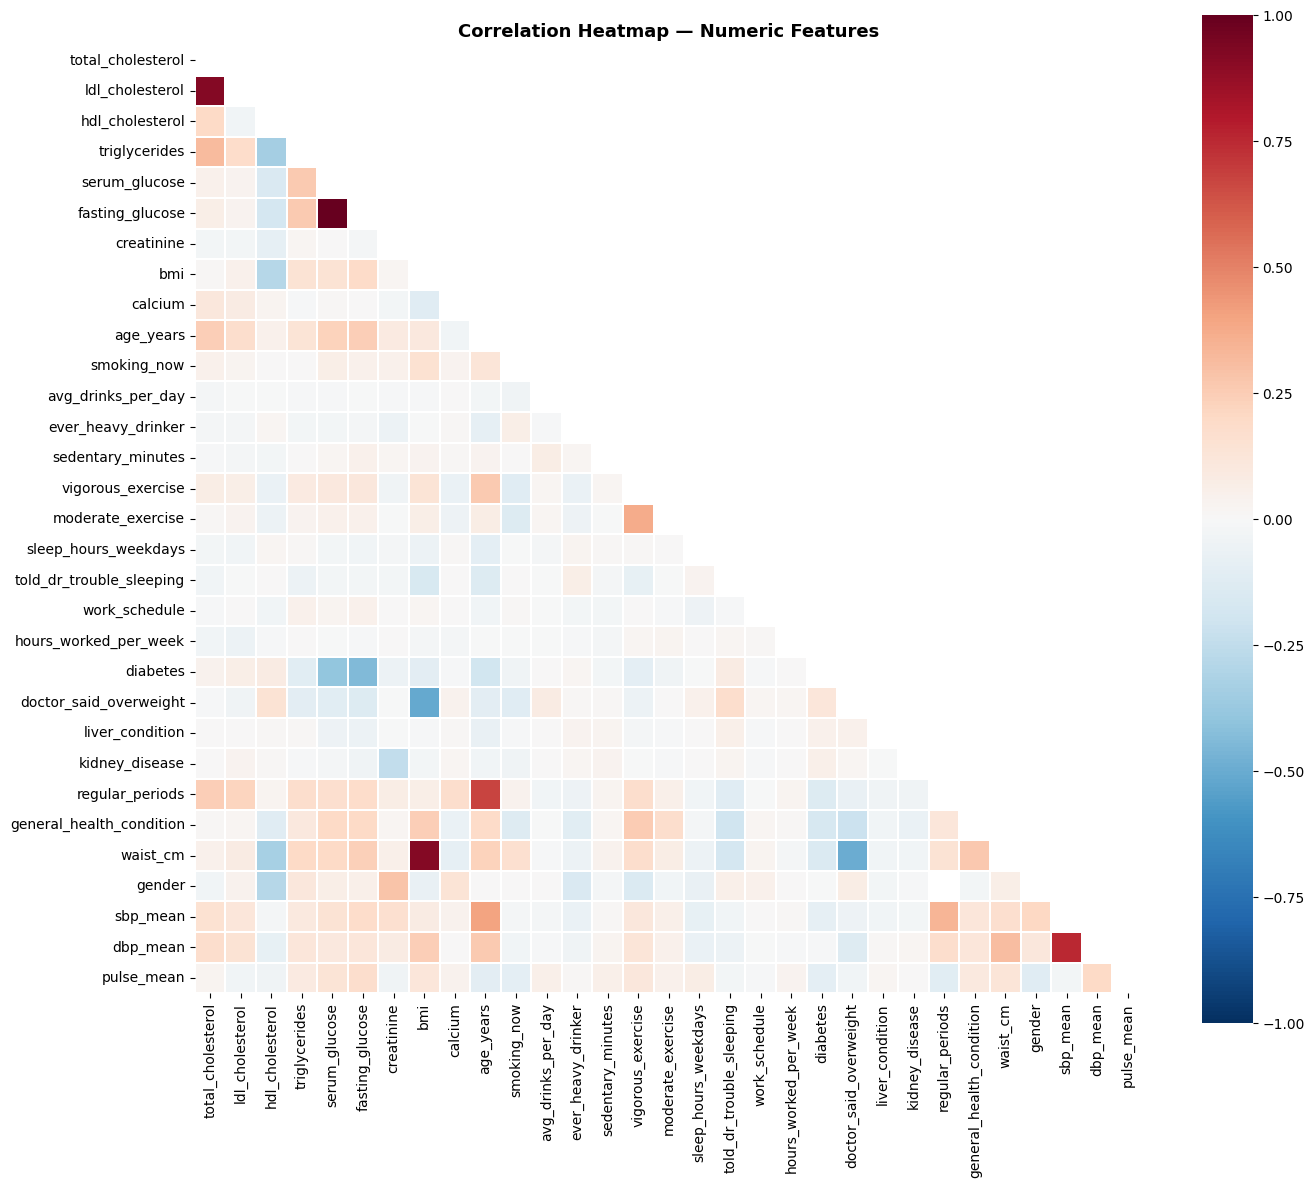

Highly correlated pairs (|r|>0.7): 4
  serum_glucose <-> fasting_glucose: 0.994
  bmi <-> waist_cm: 0.921
  total_cholesterol <-> ldl_cholesterol: 0.918
  sbp_mean <-> dbp_mean: 0.753


In [6]:
# Correlation heatmap of numeric features
corr_feats = [c for c in numeric_feats if df[c].isnull().mean() < 0.7]
corr_matrix = df[corr_feats].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0.3, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Show highly correlated pairs
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i, j]
        if abs(v) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(v, 3)))
if high_corr:
    print(f'Highly correlated pairs (|r|>0.7): {len(high_corr)}')
    for a, b, v in sorted(high_corr, key=lambda x: -abs(x[2]))[:10]:
        print(f'  {a} <-> {b}: {v}')

## Section 3: Feature Groups

In [7]:
LAB_FEATURES = [c for c in [
    'total_cholesterol','ldl_cholesterol','hdl_cholesterol','triglycerides',
    'serum_glucose','fasting_glucose','creatinine',
    'sbp_mean','dbp_mean','pulse_mean','bmi','calcium','age_years'
] if c in df.columns]

QUEST_FEATURES = [c for c in [
    'smoking_now','cigarettes_per_day','avg_drinks_per_day','ever_heavy_drinker',
    'sedentary_minutes','vigorous_exercise','moderate_exercise',
    'sleep_hours_weekdays','told_dr_trouble_sleeping','work_schedule',
    'hours_worked_per_week','diabetes','doctor_said_overweight','liver_condition',
    'kidney_disease','regular_periods','general_health_condition','waist_cm','gender'
] if c in df.columns]

ALL_FEATURES = list(dict.fromkeys(LAB_FEATURES + QUEST_FEATURES))
print(f'LAB: {len(LAB_FEATURES)}, QUEST: {len(QUEST_FEATURES)}, ALL: {len(ALL_FEATURES)}')
print('LAB:', LAB_FEATURES)
print('QUEST:', QUEST_FEATURES)

LAB: 13, QUEST: 19, ALL: 32
LAB: ['total_cholesterol', 'ldl_cholesterol', 'hdl_cholesterol', 'triglycerides', 'serum_glucose', 'fasting_glucose', 'creatinine', 'sbp_mean', 'dbp_mean', 'pulse_mean', 'bmi', 'calcium', 'age_years']
QUEST: ['smoking_now', 'cigarettes_per_day', 'avg_drinks_per_day', 'ever_heavy_drinker', 'sedentary_minutes', 'vigorous_exercise', 'moderate_exercise', 'sleep_hours_weekdays', 'told_dr_trouble_sleeping', 'work_schedule', 'hours_worked_per_week', 'diabetes', 'doctor_said_overweight', 'liver_condition', 'kidney_disease', 'regular_periods', 'general_health_condition', 'waist_cm', 'gender']


## Section 4: Preprocessing

In [8]:
def add_missing_flags(df_feat):
    flags = {f'{c}_miss': df_feat[c].isnull().astype(int)
             for c in df_feat.columns if df_feat[c].isnull().any()}
    return pd.concat([df_feat, pd.DataFrame(flags, index=df_feat.index)], axis=1) if flags else df_feat

X_lab_full   = add_missing_flags(df[LAB_FEATURES])
X_quest_full = add_missing_flags(df[QUEST_FEATURES])
X_all_full   = add_missing_flags(df[ALL_FEATURES])
y_full       = df[TARGET]

_idx = np.arange(len(df))
tr_idx, te_idx = train_test_split(_idx, test_size=0.2, stratify=y_full.values, random_state=SEED)
X_tr = X_all_full.iloc[tr_idx]; X_te = X_all_full.iloc[te_idx]
y_tr = y_full.iloc[tr_idx];     y_te = y_full.iloc[te_idx]
print(f'Train: {len(tr_idx):,} | Test: {len(te_idx):,}')
print(f'Train positive rate: {y_tr.mean()*100:.1f}% | Test: {y_te.mean()*100:.1f}%')

def make_lr(C=1.0, penalty='l2'):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', LogisticRegression(penalty=penalty, C=C, class_weight='balanced',
                                   max_iter=2000, random_state=SEED,
                                   solver='liblinear' if penalty=='l1' else 'lbfgs'))
    ])

def make_rf():
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                        random_state=SEED, n_jobs=-1))
    ])

THR = 0.3
print(f'\nFeature matrix shapes:')
print(f'  X_all_full: {X_all_full.shape}')
print(f'  X_lab_full: {X_lab_full.shape}')
print(f'  X_quest_full: {X_quest_full.shape}')

Train: 5,942 | Test: 1,486
Train positive rate: 32.4% | Test: 32.4%

Feature matrix shapes:
  X_all_full: (7428, 56)
  X_lab_full: (7428, 25)
  X_quest_full: (7428, 31)


## Section 5: Baseline Models (LR L2 & L1)

In [9]:
def eval_model(model, X_te, y_te, thr=0.3, name=''):
    prob = model.predict_proba(X_te)[:, 1]
    pred = (prob >= thr).astype(int)
    return {
        'name': name, 'prob': prob,
        'ROC-AUC':        round(roc_auc_score(y_te, prob), 4),
        'Avg Precision':  round(average_precision_score(y_te, prob), 4),
        'Recall':         round(recall_score(y_te, pred, zero_division=0), 4),
        'Precision':      round(precision_score(y_te, pred, zero_division=0), 4),
        'Accuracy':       round(accuracy_score(y_te, pred), 4),
        'F1':             round(f1_score(y_te, pred, zero_division=0), 4),
    }

lr_l2 = make_lr(C=1.0, penalty='l2'); lr_l2.fit(X_tr, y_tr)
lr_l1 = make_lr(C=1.0, penalty='l1'); lr_l1.fit(X_tr, y_tr)

res_l2 = eval_model(lr_l2, X_te, y_te, THR, 'LR L2')
res_l1 = eval_model(lr_l1, X_te, y_te, THR, 'LR L1')
for r in [res_l2, res_l1]:
    print(f"{r['name']:12} ROC-AUC={r['ROC-AUC']} Recall={r['Recall']} Prec={r['Precision']} F1={r['F1']}")

LR L2        ROC-AUC=0.7791 Recall=0.9439 Prec=0.4303 F1=0.5911
LR L1        ROC-AUC=0.7796 Recall=0.9439 Prec=0.4299 F1=0.5908


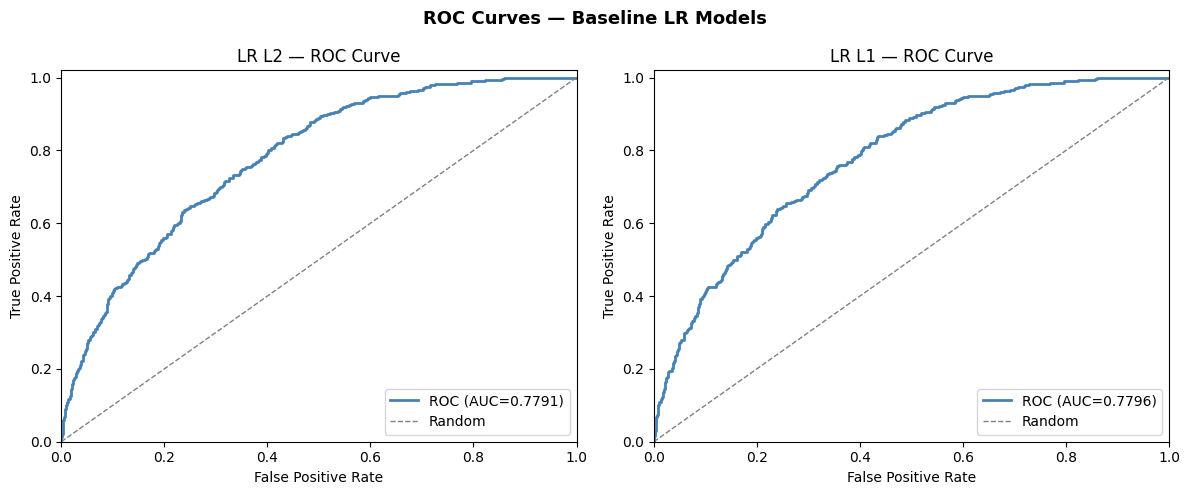

In [10]:
# ROC curves for LR L2 and LR L1 side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res, model_name in zip(axes, [res_l2, res_l1], ['LR L2', 'LR L1']):
    fpr, tpr, _ = roc_curve(y_te, res['prob'])
    auc = res['ROC-AUC']
    ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'ROC (AUC={auc})')
    ax.plot([0,1],[0,1],'--', color='gray', lw=1, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} — ROC Curve')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.suptitle('ROC Curves — Baseline LR Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

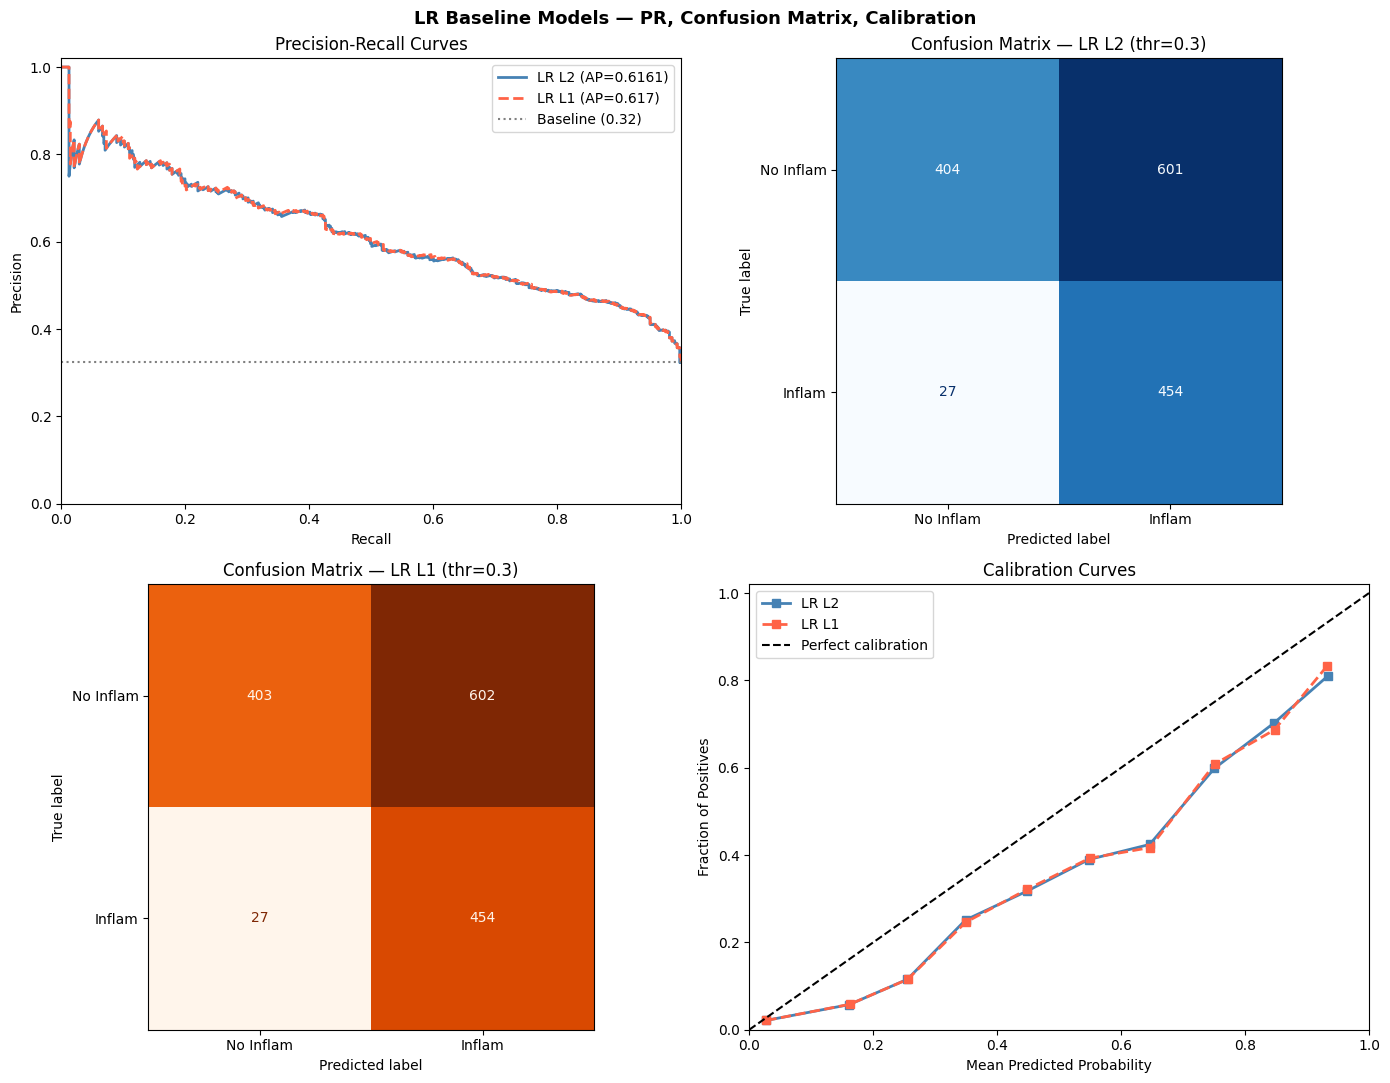

In [11]:
# PR curves, Confusion matrices, Calibration curves — 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# PR curves
ax = axes[0, 0]
for res, col, ls in [(res_l2, 'steelblue', '-'), (res_l1, 'tomato', '--')]:
    prec, rec, _ = precision_recall_curve(y_te, res['prob'])
    ap = res['Avg Precision']
    ax.plot(rec, prec, lw=2, color=col, linestyle=ls, label=f"{res['name']} (AP={ap})")
baseline_pr = y_te.mean()
ax.axhline(baseline_pr, color='gray', linestyle=':', lw=1.5, label=f'Baseline ({baseline_pr:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

# Confusion matrix LR L2
ax = axes[0, 1]
pred_l2 = (res_l2['prob'] >= THR).astype(int)
cm = confusion_matrix(y_te, pred_l2)
ConfusionMatrixDisplay(cm, display_labels=['No Inflam', 'Inflam']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — LR L2 (thr={THR})')

# Confusion matrix LR L1
ax = axes[1, 0]
pred_l1 = (res_l1['prob'] >= THR).astype(int)
cm1 = confusion_matrix(y_te, pred_l1)
ConfusionMatrixDisplay(cm1, display_labels=['No Inflam', 'Inflam']).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'Confusion Matrix — LR L1 (thr={THR})')

# Calibration curves
ax = axes[1, 1]
for res, col, ls in [(res_l2, 'steelblue', '-'), (res_l1, 'tomato', '--')]:
    frac_pos, mean_pred = calibration_curve(y_te, res['prob'], n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', color=col, linestyle=ls, lw=2, label=res['name'])
ax.plot([0,1],[0,1],'k--', lw=1.5, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves')
ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle('LR Baseline Models — PR, Confusion Matrix, Calibration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Optimal threshold for recall>=0.85: 0.360
  Recall=0.898, Precision=0.458, F1=0.607


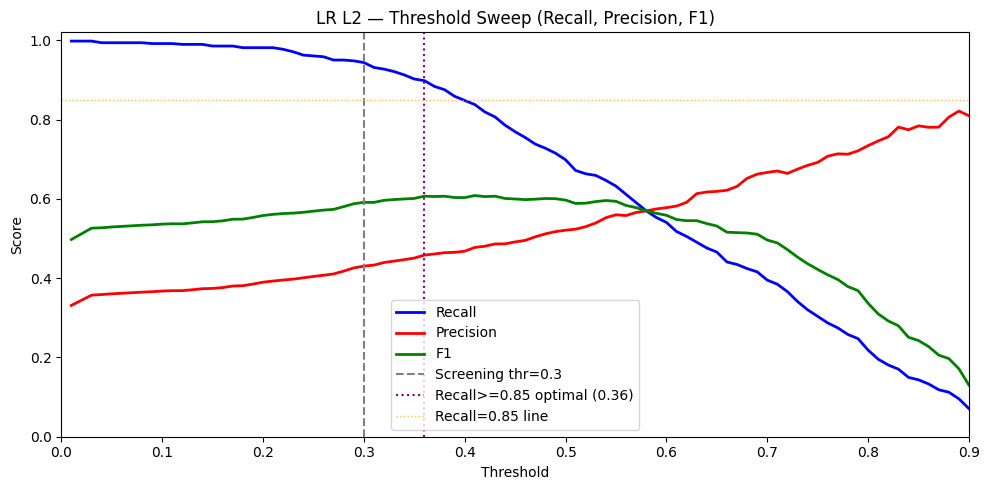

In [12]:
# Threshold sweep for LR L2
thresholds = np.linspace(0.01, 0.90, 90)
probs_l2 = res_l2['prob']

recalls, precisions, f1s = [], [], []
for t in thresholds:
    pred = (probs_l2 >= t).astype(int)
    recalls.append(recall_score(y_te, pred, zero_division=0))
    precisions.append(precision_score(y_te, pred, zero_division=0))
    f1s.append(f1_score(y_te, pred, zero_division=0))

# Find optimal threshold for recall >= 0.85
recall_arr = np.array(recalls)
f1_arr = np.array(f1s)
recall_mask = recall_arr >= 0.85
if recall_mask.any():
    best_thr_idx = np.argmax(f1_arr * recall_mask)
    best_thr_recall85 = thresholds[best_thr_idx]
    print(f'Optimal threshold for recall>=0.85: {best_thr_recall85:.3f}')
    print(f'  Recall={recalls[best_thr_idx]:.3f}, Precision={precisions[best_thr_idx]:.3f}, F1={f1s[best_thr_idx]:.3f}')
else:
    best_thr_recall85 = 0.3
    print('No threshold achieves recall>=0.85')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, recalls, 'b-', lw=2, label='Recall')
ax.plot(thresholds, precisions, 'r-', lw=2, label='Precision')
ax.plot(thresholds, f1s, 'g-', lw=2, label='F1')
ax.axvline(THR, color='gray', linestyle='--', lw=1.5, label=f'Screening thr={THR}')
ax.axvline(best_thr_recall85, color='purple', linestyle=':', lw=1.5, label=f'Recall>=0.85 optimal ({best_thr_recall85:.2f})')
ax.axhline(0.85, color='orange', linestyle=':', lw=1, alpha=0.7, label='Recall=0.85 line')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('LR L2 — Threshold Sweep (Recall, Precision, F1)')
ax.legend(); ax.set_xlim([0, 0.9]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

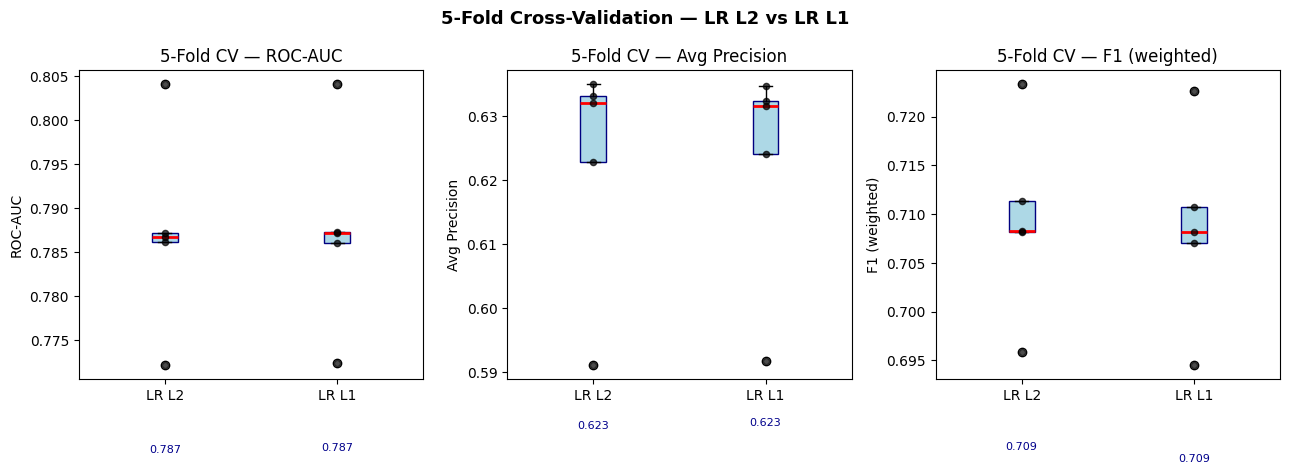

LR L2: ROC-AUC=0.7873+/-0.0101  AP=0.6228+/-0.0164
LR L1: ROC-AUC=0.7874+/-0.0101  AP=0.6228+/-0.0160


In [13]:
# 5-fold CV box plots for LR L2 and LR L1
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'roc_auc': 'roc_auc', 'average_precision': 'average_precision', 'f1': 'f1_weighted'}

cv_l2 = cross_validate(make_lr(C=1.0, penalty='l2'), X_all_full, y_full, cv=cv5, scoring=scoring)
cv_l1 = cross_validate(make_lr(C=1.0, penalty='l1'), X_all_full, y_full, cv=cv5, scoring=scoring)

metrics_plot = ['test_roc_auc', 'test_average_precision', 'test_f1']
metric_labels = ['ROC-AUC', 'Avg Precision', 'F1 (weighted)']

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, metric, label in zip(axes, metrics_plot, metric_labels):
    data = [cv_l2[metric], cv_l1[metric]]
    ax.boxplot(data, labels=['LR L2', 'LR L1'], patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', lw=2))
    ax.set_title(f'5-Fold CV — {label}')
    ax.set_ylabel(label)
    for i, vals in enumerate(data, 1):
        ax.scatter([i]*5, vals, color='black', s=20, zorder=5, alpha=0.7)
        ax.text(i, min(vals)-0.01, f'{np.mean(vals):.3f}', ha='center', fontsize=8, color='darkblue')

plt.suptitle('5-Fold Cross-Validation — LR L2 vs LR L1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for name, cv_res in [('LR L2', cv_l2), ('LR L1', cv_l1)]:
    print(f'{name}: ROC-AUC={cv_res["test_roc_auc"].mean():.4f}+/-{cv_res["test_roc_auc"].std():.4f}  AP={cv_res["test_average_precision"].mean():.4f}+/-{cv_res["test_average_precision"].std():.4f}')

## Section 6: Tree Models (RF & XGBoost)

RF           ROC-AUC=0.7872 Recall=0.8025 Prec=0.5046 F1=0.6196
XGBoost      ROC-AUC=0.7672 Recall=0.6653 Prec=0.5186 F1=0.5829


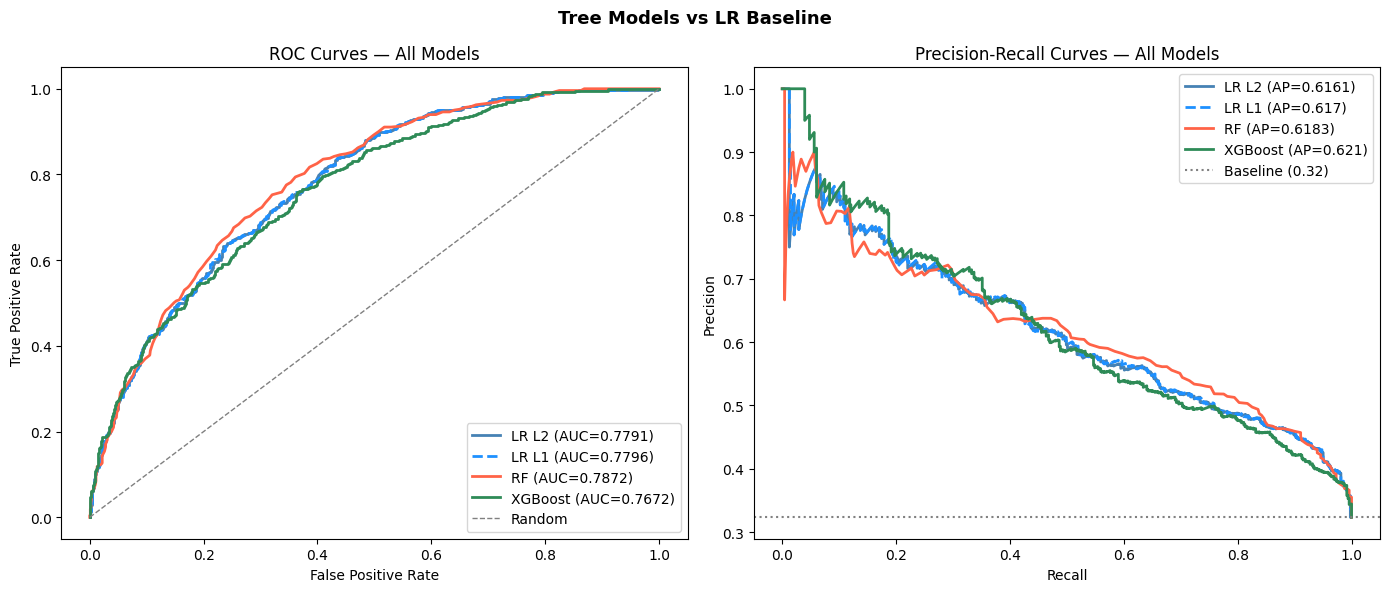

In [14]:
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
rf = make_rf(); rf.fit(X_tr, y_tr)
xgb_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', XGBClassifier(n_estimators=200, scale_pos_weight=spw,
                          random_state=SEED, eval_metric='logloss',
                          verbosity=0))
])
xgb_pipe.fit(X_tr, y_tr)
res_rf  = eval_model(rf, X_te, y_te, THR, 'RF')
res_xgb = eval_model(xgb_pipe, X_te, y_te, THR, 'XGBoost')
for r in [res_rf, res_xgb]:
    print(f"{r['name']:12} ROC-AUC={r['ROC-AUC']} Recall={r['Recall']} Prec={r['Precision']} F1={r['F1']}")

# Comparison plots: ROC and PR side by side vs LR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for res, col, ls in [(res_l2,'steelblue','-'), (res_l1,'dodgerblue','--'), (res_rf,'tomato','-'), (res_xgb,'seagreen','-')]:
    fpr, tpr, _ = roc_curve(y_te, res['prob'])
    ax.plot(fpr, tpr, lw=2, color=col, linestyle=ls, label=f"{res['name']} (AUC={res['ROC-AUC']})")
ax.plot([0,1],[0,1],'--',color='gray',lw=1,label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models'); ax.legend(loc='lower right')

ax = axes[1]
for res, col, ls in [(res_l2,'steelblue','-'), (res_l1,'dodgerblue','--'), (res_rf,'tomato','-'), (res_xgb,'seagreen','-')]:
    prec, rec, _ = precision_recall_curve(y_te, res['prob'])
    ax.plot(rec, prec, lw=2, color=col, linestyle=ls, label=f"{res['name']} (AP={res['Avg Precision']})")
ax.axhline(y_te.mean(), color='gray', linestyle=':',lw=1.5,label=f'Baseline ({y_te.mean():.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models'); ax.legend()

plt.suptitle('Tree Models vs LR Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

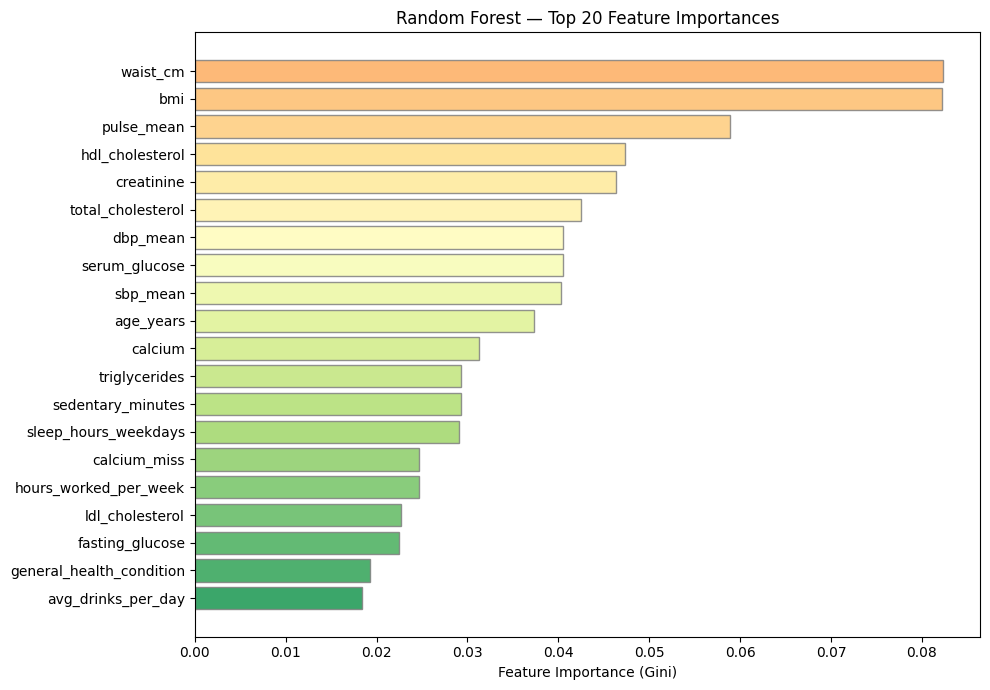

Top 10 RF features:
waist_cm             0.082279
bmi                  0.082227
pulse_mean           0.058908
hdl_cholesterol      0.047326
creatinine           0.046390
total_cholesterol    0.042523
dbp_mean             0.040518
serum_glucose        0.040481
sbp_mean             0.040239
age_years            0.037360


In [15]:
# RF Feature importances (top 20)
rf_imp = rf.named_steps['clf'].feature_importances_
feat_names = X_all_full.columns.tolist()
rf_imp_series = pd.Series(rf_imp, index=feat_names).sort_values(ascending=False)
top20_rf = rf_imp_series.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 20))[::-1]
ax.barh(top20_rf.index[::-1], top20_rf.values[::-1], color=colors, edgecolor='gray', alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Top 20 Feature Importances')
plt.tight_layout()
plt.show()
print('Top 10 RF features:')
print(top20_rf.head(10).to_string())

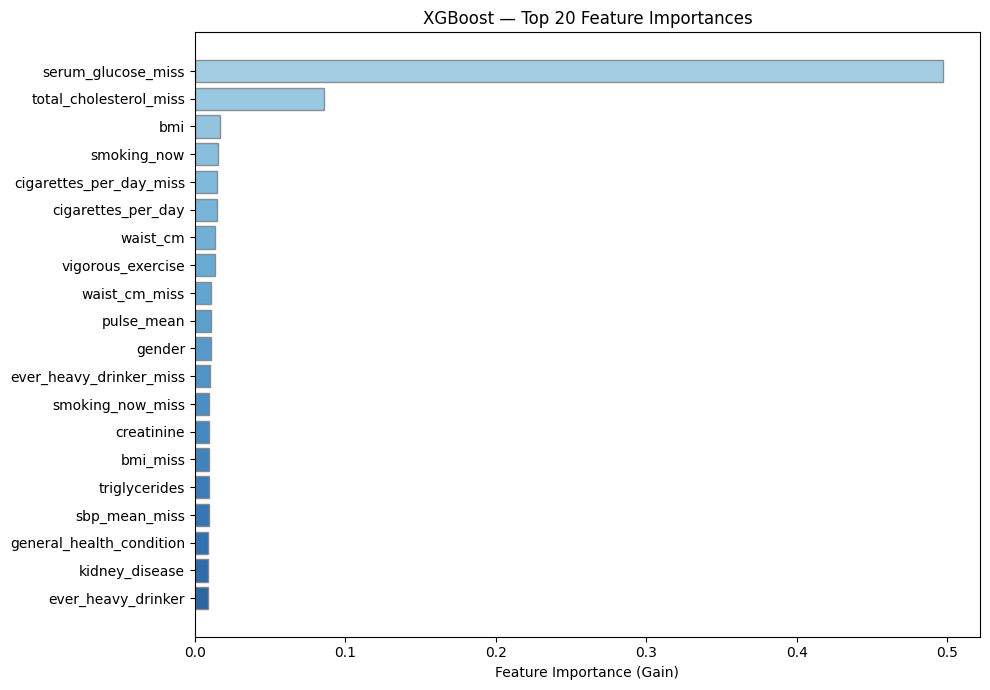

Top 10 XGBoost features:
serum_glucose_miss         0.497022
total_cholesterol_miss     0.086104
bmi                        0.016825
smoking_now                0.015483
cigarettes_per_day_miss    0.014837
cigarettes_per_day         0.014415
waist_cm                   0.013461
vigorous_exercise          0.013328
waist_cm_miss              0.010952
pulse_mean                 0.010676


In [16]:
# XGBoost feature importances (top 20)
xgb_model = xgb_pipe.named_steps['clf']
xgb_imp = xgb_model.feature_importances_
xgb_feat_names = X_all_full.columns.tolist()
xgb_imp_series = pd.Series(xgb_imp, index=xgb_feat_names).sort_values(ascending=False)
top20_xgb = xgb_imp_series.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_xgb = plt.cm.Blues(np.linspace(0.4, 0.9, 20))[::-1]
ax.barh(top20_xgb.index[::-1], top20_xgb.values[::-1], color=colors_xgb, edgecolor='gray', alpha=0.85)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost — Top 20 Feature Importances')
plt.tight_layout()
plt.show()
print('Top 10 XGBoost features:')
print(top20_xgb.head(10).to_string())

## Section 7: Calibration

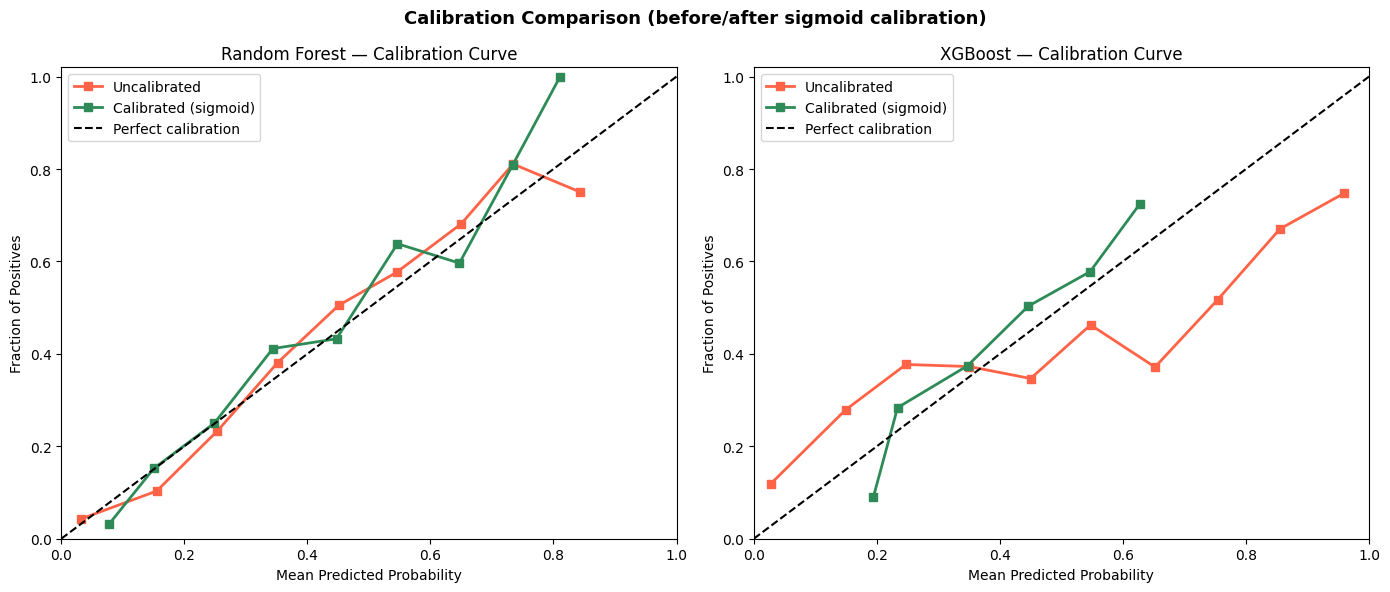

RF-Cal       ROC-AUC=0.7714 Recall=0.7297 Prec=0.5247
XGB-Cal      ROC-AUC=0.7576 Recall=0.6383 Prec=0.5203


In [17]:
# Calibrate RF and XGBoost with sigmoid on a calibration holdout
tr_idx2, cal_idx = train_test_split(tr_idx, test_size=0.2, stratify=y_full.values[tr_idx], random_state=SEED)

rf_cal_base = make_rf()
rf_cal_base.fit(X_all_full.iloc[tr_idx2], y_full.iloc[tr_idx2])

xgb_cal_base = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', XGBClassifier(n_estimators=200, scale_pos_weight=spw,
                          random_state=SEED, eval_metric='logloss',
                          verbosity=0))
])
xgb_cal_base.fit(X_all_full.iloc[tr_idx2], y_full.iloc[tr_idx2])

rf_calibrated = CalibratedClassifierCV(rf_cal_base, method='sigmoid', cv=None)
rf_calibrated.fit(X_all_full.iloc[cal_idx], y_full.iloc[cal_idx])

xgb_calibrated = CalibratedClassifierCV(xgb_cal_base, method='sigmoid', cv=None)
xgb_calibrated.fit(X_all_full.iloc[cal_idx], y_full.iloc[cal_idx])

prob_rf_raw  = rf.predict_proba(X_te)[:, 1]
prob_rf_cal  = rf_calibrated.predict_proba(X_te)[:, 1]
prob_xgb_raw = xgb_pipe.predict_proba(X_te)[:, 1]
prob_xgb_cal = xgb_calibrated.predict_proba(X_te)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, raw, cal, title in [
    (axes[0], prob_rf_raw, prob_rf_cal, 'Random Forest'),
    (axes[1], prob_xgb_raw, prob_xgb_cal, 'XGBoost')
]:
    frac_raw, mean_raw = calibration_curve(y_te, raw, n_bins=10)
    frac_cal, mean_cal = calibration_curve(y_te, cal, n_bins=10)
    ax.plot(mean_raw, frac_raw, 's-', lw=2, color='tomato', label='Uncalibrated')
    ax.plot(mean_cal, frac_cal, 's-', lw=2, color='seagreen', label='Calibrated (sigmoid)')
    ax.plot([0,1],[0,1],'k--', lw=1.5, label='Perfect calibration')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'{title} — Calibration Curve')
    ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle('Calibration Comparison (before/after sigmoid calibration)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

res_rf_cal  = eval_model(rf_calibrated,  X_te, y_te, THR, 'RF-Cal')
res_xgb_cal = eval_model(xgb_calibrated, X_te, y_te, THR, 'XGB-Cal')
for r in [res_rf_cal, res_xgb_cal]:
    print(f"{r['name']:12} ROC-AUC={r['ROC-AUC']} Recall={r['Recall']} Prec={r['Precision']}")

## Section 8: Ensemble

In [18]:
# Train domain-split base models on full data for test prediction
lr_labs  = make_lr(); lr_labs.fit(X_lab_full.iloc[tr_idx],   y_tr)
lr_quest = make_lr(); lr_quest.fit(X_quest_full.iloc[tr_idx], y_tr)
rf_all   = make_rf(); rf_all.fit(X_all_full.iloc[tr_idx],    y_tr)

# OOF stacking
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
oof_lab   = cross_val_predict(make_lr(), X_lab_full,   y_full, cv=cv3, method='predict_proba')[:,1]
oof_quest = cross_val_predict(make_lr(), X_quest_full, y_full, cv=cv3, method='predict_proba')[:,1]
oof_rf    = cross_val_predict(make_rf(), X_all_full,   y_full, cv=cv3, method='predict_proba')[:,1]

meta_X = np.column_stack([oof_lab, oof_quest, oof_rf])
meta_lr = LogisticRegression(C=1.0, class_weight='balanced', random_state=SEED)
meta_lr.fit(meta_X[tr_idx], y_tr)

print('OOF stacking meta-learner trained.')
print(f'Meta-LR coefficients: {meta_lr.coef_[0].round(3)}')

OOF stacking meta-learner trained.
Meta-LR coefficients: [1.892 0.999 3.312]



--- Ensemble Comparison ---
LR L2        ROC-AUC=0.7791 AP=0.6161 Recall=0.9439 Prec=0.4303 F1=0.5911
LR L1        ROC-AUC=0.7796 AP=0.617 Recall=0.9439 Prec=0.4299 F1=0.5908
RF           ROC-AUC=0.7872 AP=0.6183 Recall=0.8025 Prec=0.5046 F1=0.6196
XGBoost      ROC-AUC=0.7672 AP=0.621 Recall=0.6653 Prec=0.5186 F1=0.5829
Stacking     ROC-AUC=0.7871 AP=0.6272 Recall=0.9127 Prec=0.443 F1=0.5965
SoftVote     ROC-AUC=0.7902 AP=0.6394 Recall=0.8191 Prec=0.4882 F1=0.6118


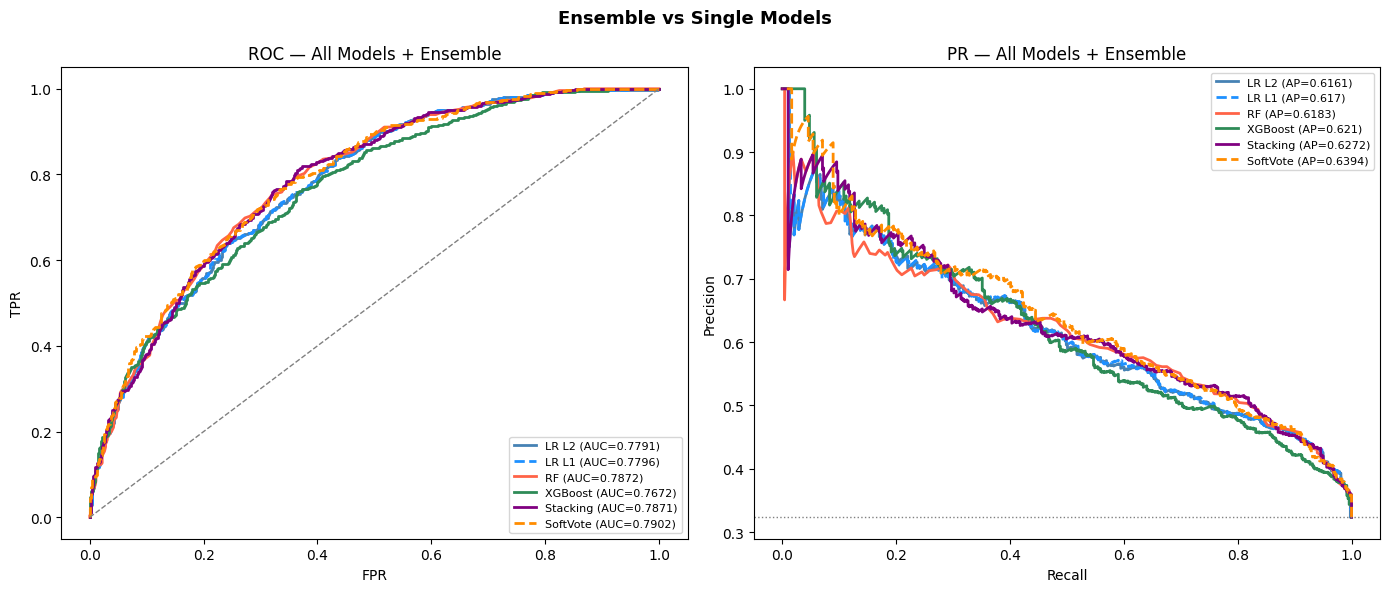

In [19]:
# Evaluate ensemble on test set
te_lab   = lr_labs.predict_proba(X_lab_full.iloc[te_idx])[:, 1]
te_quest = lr_quest.predict_proba(X_quest_full.iloc[te_idx])[:, 1]
te_rf    = rf_all.predict_proba(X_all_full.iloc[te_idx])[:, 1]

meta_te_X = np.column_stack([te_lab, te_quest, te_rf])
prob_stack = meta_lr.predict_proba(meta_te_X)[:, 1]

# Soft vote ensemble
prob_softv = (res_l2['prob'] + res_rf['prob'] + res_xgb['prob']) / 3

pred_stack = (prob_stack >= THR).astype(int)
pred_softv = (prob_softv >= THR).astype(int)

res_stack = {
    'name': 'Stacking',
    'prob': prob_stack,
    'ROC-AUC':       round(roc_auc_score(y_te, prob_stack), 4),
    'Avg Precision': round(average_precision_score(y_te, prob_stack), 4),
    'Recall':        round(recall_score(y_te, pred_stack, zero_division=0), 4),
    'Precision':     round(precision_score(y_te, pred_stack, zero_division=0), 4),
    'Accuracy':      round(accuracy_score(y_te, pred_stack), 4),
    'F1':            round(f1_score(y_te, pred_stack, zero_division=0), 4),
}
res_softv = {
    'name': 'SoftVote',
    'prob': prob_softv,
    'ROC-AUC':       round(roc_auc_score(y_te, prob_softv), 4),
    'Avg Precision': round(average_precision_score(y_te, prob_softv), 4),
    'Recall':        round(recall_score(y_te, pred_softv, zero_division=0), 4),
    'Precision':     round(precision_score(y_te, pred_softv, zero_division=0), 4),
    'Accuracy':      round(accuracy_score(y_te, pred_softv), 4),
    'F1':            round(f1_score(y_te, pred_softv, zero_division=0), 4),
}

all_results = [res_l2, res_l1, res_rf, res_xgb, res_stack, res_softv]

print('\n--- Ensemble Comparison ---')
for r in all_results:
    print(f"{r['name']:12} ROC-AUC={r['ROC-AUC']} AP={r['Avg Precision']} Recall={r['Recall']} Prec={r['Precision']} F1={r['F1']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_ens = ['steelblue', 'dodgerblue', 'tomato', 'seagreen', 'purple', 'darkorange']
ls_ens = ['-', '--', '-', '-', '-', '--']

ax = axes[0]
for res, col, ls in zip(all_results, colors_ens, ls_ens):
    fpr, tpr, _ = roc_curve(y_te, res['prob'])
    ax.plot(fpr, tpr, lw=2, color=col, linestyle=ls, label=f"{res['name']} (AUC={res['ROC-AUC']})")
ax.plot([0,1],[0,1],'--',color='gray',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC — All Models + Ensemble')
ax.legend(loc='lower right', fontsize=8)

ax = axes[1]
for res, col, ls in zip(all_results, colors_ens, ls_ens):
    prec, rec, _ = precision_recall_curve(y_te, res['prob'])
    ax.plot(rec, prec, lw=2, color=col, linestyle=ls, label=f"{res['name']} (AP={res['Avg Precision']})")
ax.axhline(y_te.mean(), color='gray', linestyle=':',lw=1)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('PR — All Models + Ensemble')
ax.legend(fontsize=8)

plt.suptitle('Ensemble vs Single Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 9: Feature Selection (LR Quest Model)

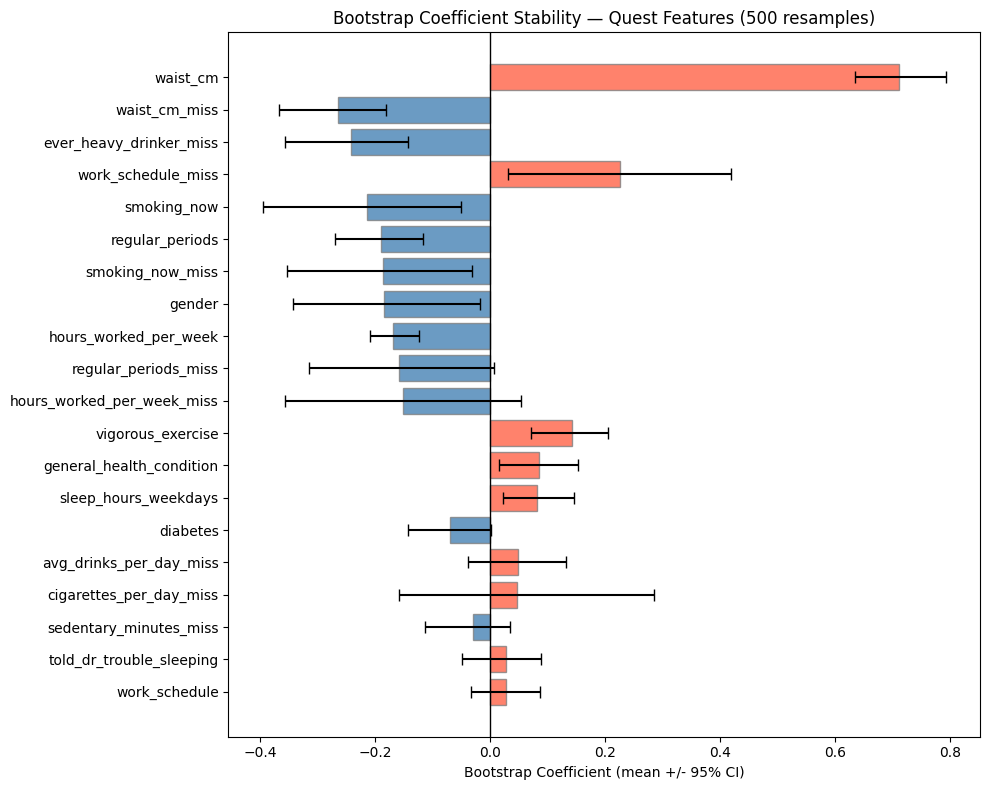

Stable positive features (5): ['vigorous_exercise', 'sleep_hours_weekdays', 'general_health_condition', 'waist_cm', 'work_schedule_miss']
Stable negative features (7): ['smoking_now', 'hours_worked_per_week', 'regular_periods', 'gender', 'smoking_now_miss', 'ever_heavy_drinker_miss', 'waist_cm_miss']


In [20]:
# Bootstrap coefficient stability (500 resamples) - QUEST_FEATURES only
from sklearn.utils import resample

X_quest_tr = X_quest_full.iloc[tr_idx]
y_quest_tr = y_tr

quest_cols = X_quest_full.columns.tolist()
n_boot = 500
boot_coefs = np.zeros((n_boot, len(quest_cols)))

lr_boot = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced',
                               max_iter=2000, random_state=SEED, solver='lbfgs')
imp_boot = SimpleImputer(strategy='median')
sc_boot  = StandardScaler()

X_quest_tr_imp = sc_boot.fit_transform(imp_boot.fit_transform(X_quest_tr))

for i in range(n_boot):
    X_b, y_b = resample(X_quest_tr_imp, y_quest_tr.values, random_state=i)
    lr_boot.fit(X_b, y_b)
    boot_coefs[i] = lr_boot.coef_[0]

coef_mean  = np.mean(boot_coefs, axis=0)
coef_std   = np.std(boot_coefs, axis=0)
coef_ci_lo = np.percentile(boot_coefs, 2.5, axis=0)
coef_ci_hi = np.percentile(boot_coefs, 97.5, axis=0)

order  = np.argsort(np.abs(coef_mean))[::-1]
top_n  = min(20, len(quest_cols))
top_idx = order[:top_n]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(top_n)
means_plot = coef_mean[top_idx]
lo_err = means_plot - coef_ci_lo[top_idx]
hi_err = coef_ci_hi[top_idx] - means_plot
colors_boot = ['tomato' if m > 0 else 'steelblue' for m in means_plot]
ax.barh(y_pos, means_plot[::-1], xerr=[lo_err[::-1], hi_err[::-1]],
        color=colors_boot[::-1], edgecolor='gray', alpha=0.8, capsize=4)
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([quest_cols[i] for i in top_idx[::-1]])
ax.set_xlabel('Bootstrap Coefficient (mean +/- 95% CI)')
ax.set_title('Bootstrap Coefficient Stability — Quest Features (500 resamples)')
plt.tight_layout()
plt.show()

stable_positive = [(quest_cols[i], coef_mean[i]) for i in range(len(quest_cols)) if coef_ci_lo[i] > 0]
stable_negative = [(quest_cols[i], coef_mean[i]) for i in range(len(quest_cols)) if coef_ci_hi[i] < 0]
print(f'Stable positive features ({len(stable_positive)}):', [x[0] for x in stable_positive])
print(f'Stable negative features ({len(stable_negative)}):', [x[0] for x in stable_negative])

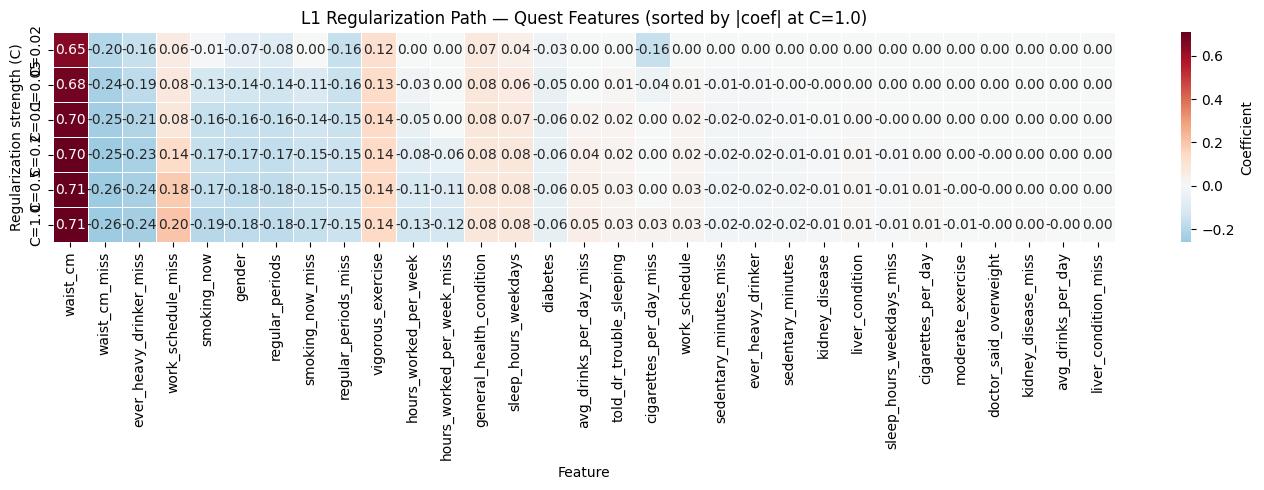

In [21]:
# L1 regularization path heatmap
C_values = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0]

coef_path = np.zeros((len(C_values), len(quest_cols)))
for j, C in enumerate(C_values):
    lr_path = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', LogisticRegression(penalty='l1', C=C, class_weight='balanced',
                                    max_iter=2000, random_state=SEED, solver='liblinear'))
    ])
    lr_path.fit(X_quest_tr, y_quest_tr)
    coef_path[j] = lr_path.named_steps['clf'].coef_[0]

coef_path_df = pd.DataFrame(coef_path, index=[f'C={c}' for c in C_values], columns=quest_cols)

sort_order = coef_path_df.loc['C=1.0'].abs().sort_values(ascending=False).index
coef_path_df_sorted = coef_path_df[sort_order]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(coef_path_df_sorted, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Coefficient'})
ax.set_title('L1 Regularization Path — Quest Features (sorted by |coef| at C=1.0)')
ax.set_xlabel('Feature'); ax.set_ylabel('Regularization strength (C)')
plt.tight_layout()
plt.show()

In [22]:
# Feature tier classification
tiers = {}
for i, col in enumerate(quest_cols):
    mean_c = coef_mean[i]
    lo_c   = coef_ci_lo[i]
    hi_c   = coef_ci_hi[i]
    ci_crosses_zero = (lo_c <= 0 <= hi_c)
    abs_mean = abs(mean_c)
    survives_l1 = (col in coef_path_df.columns) and (abs(coef_path_df.loc['C=0.2', col]) > 0.01)

    if not ci_crosses_zero and survives_l1:
        tiers[col] = 'STRONG'
    elif abs_mean > 0.05:
        tiers[col] = 'BORDERLINE'
    else:
        tiers[col] = 'REMOVE'

tier_df = pd.DataFrame([
    {'feature': col, 'tier': tier, 'mean_coef': round(coef_mean[i], 4),
     'ci_lo': round(coef_ci_lo[i], 4), 'ci_hi': round(coef_ci_hi[i], 4)}
    for i, (col, tier) in enumerate(tiers.items())
]).sort_values('tier').reset_index(drop=True)

print('Feature Tier Classification:')
print(tier_df.to_string(index=False))
print(f"\nSTRONG: {(tier_df.tier=='STRONG').sum()}")
print(f"BORDERLINE: {(tier_df.tier=='BORDERLINE').sum()}")
print(f"REMOVE: {(tier_df.tier=='REMOVE').sum()}")

STRONG_QUEST    = tier_df.loc[tier_df.tier=='STRONG',     'feature'].tolist()
BORDERLINE_QUEST = tier_df.loc[tier_df.tier=='BORDERLINE', 'feature'].tolist()
STRONG_QUEST_BASE    = [f for f in STRONG_QUEST    if f in QUEST_FEATURES]
BORDERLINE_QUEST_BASE = [f for f in BORDERLINE_QUEST if f in QUEST_FEATURES]

Feature Tier Classification:
                   feature       tier  mean_coef   ci_lo   ci_hi
hours_worked_per_week_miss BORDERLINE    -0.1508 -0.3570  0.0542
      regular_periods_miss BORDERLINE    -0.1579 -0.3139  0.0064
                  diabetes BORDERLINE    -0.0688 -0.1421  0.0016
    sedentary_minutes_miss     REMOVE    -0.0297 -0.1129  0.0345
 sleep_hours_weekdays_miss     REMOVE    -0.0154 -0.0947  0.0604
            kidney_disease     REMOVE    -0.0207 -0.1192  0.0384
           liver_condition     REMOVE     0.0109 -0.0436  0.0745
    doctor_said_overweight     REMOVE    -0.0108 -0.0847  0.0638
   cigarettes_per_day_miss     REMOVE     0.0473 -0.1578  0.2857
   avg_drinks_per_day_miss     REMOVE     0.0491 -0.0383  0.1324
  told_dr_trouble_sleeping     REMOVE     0.0276 -0.0481  0.0881
      liver_condition_miss     REMOVE     0.0011 -0.0294  0.0311
         moderate_exercise     REMOVE    -0.0085 -0.0772  0.0592
       kidney_disease_miss     REMOVE     0.0011 -0.0294  0.0


Feature Selection CV Results:
All Quest                 n= 19 ROC-AUC=0.7318+/-0.0109  AP=0.5554+/-0.0184
STRONG only               n=  8 ROC-AUC=0.7322+/-0.0104  AP=0.5573+/-0.0189
STRONG+BORDERLINE         n=  9 ROC-AUC=0.7328+/-0.0101  AP=0.5579+/-0.0169


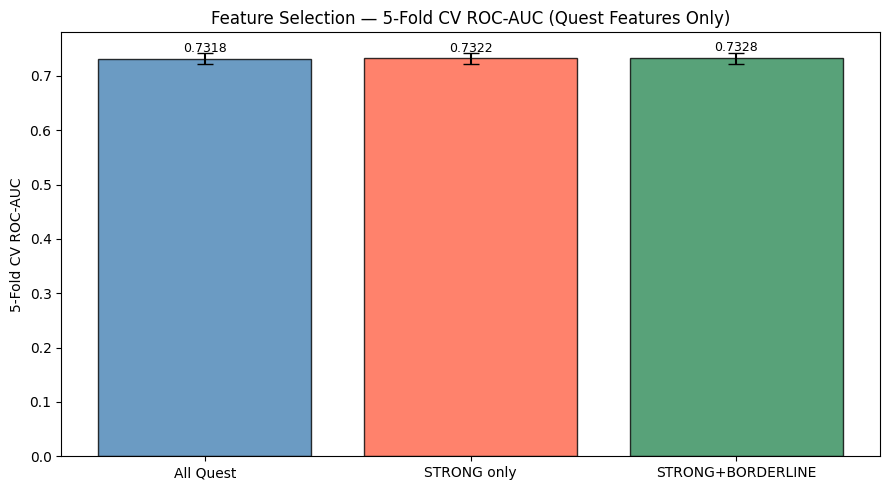

In [23]:
# Cross-validate 3 feature set sizes
feat_sets = {
    'All Quest':          QUEST_FEATURES,
    'STRONG only':        STRONG_QUEST_BASE    if STRONG_QUEST_BASE    else QUEST_FEATURES[:5],
    'STRONG+BORDERLINE':  (STRONG_QUEST_BASE + BORDERLINE_QUEST_BASE)
                          if (STRONG_QUEST_BASE or BORDERLINE_QUEST_BASE) else QUEST_FEATURES,
}

cv5_fs = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fs_results = {}
for name, feats in feat_sets.items():
    if not feats:
        feats = QUEST_FEATURES
    X_fs = add_missing_flags(df[feats])
    cv_res = cross_validate(
        make_lr(), X_fs, y_full, cv=cv5_fs,
        scoring={'roc_auc': 'roc_auc', 'average_precision': 'average_precision'}
    )
    fs_results[name] = {
        'n_feats':       len(feats),
        'roc_auc_mean':  cv_res['test_roc_auc'].mean(),
        'roc_auc_std':   cv_res['test_roc_auc'].std(),
        'ap_mean':       cv_res['test_average_precision'].mean(),
        'ap_std':        cv_res['test_average_precision'].std(),
    }

print('\nFeature Selection CV Results:')
for name, r in fs_results.items():
    print(f"{name:25} n={r['n_feats']:3d} ROC-AUC={r['roc_auc_mean']:.4f}+/-{r['roc_auc_std']:.4f}  AP={r['ap_mean']:.4f}+/-{r['ap_std']:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
names  = list(fs_results.keys())
means  = [fs_results[n]['roc_auc_mean'] for n in names]
stds   = [fs_results[n]['roc_auc_std']  for n in names]
ax.bar(names, means, yerr=stds, capsize=6, color=['steelblue','tomato','seagreen'], edgecolor='black', alpha=0.8)
ax.set_ylabel('5-Fold CV ROC-AUC')
ax.set_title('Feature Selection — 5-Fold CV ROC-AUC (Quest Features Only)')
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.002, f'{m:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Section 10: Master Comparison Table

In [24]:
# Build master comparison DataFrame
all_res = [res_l2, res_l1, res_rf, res_xgb, res_rf_cal, res_xgb_cal, res_stack, res_softv]

comparison_rows = []
for r in all_res:
    comparison_rows.append({
        'Model':         r['name'],
        'ROC-AUC':       r['ROC-AUC'],
        'Avg Precision': r['Avg Precision'],
        'Recall':        r['Recall'],
        'Precision':     r['Precision'],
        'F1':            r['F1'],
        'Accuracy':      r['Accuracy'],
        'Threshold':     THR,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('=== Master Comparison Table (thr=0.3) ===')
print(comparison_df.to_string(index=False))

# Optimal threshold table
print('\n=== Optimal Threshold Table (maximizes F1) ===')
opt_rows = []
thresholds_sweep = np.linspace(0.01, 0.99, 99)
for r in all_res:
    best_f1, best_thr, best_rec, best_prec = 0, 0.5, 0, 0
    for t in thresholds_sweep:
        pred = (r['prob'] >= t).astype(int)
        f1   = f1_score(y_te, pred, zero_division=0)
        if f1 > best_f1:
            best_f1   = f1
            best_thr  = t
            best_rec  = recall_score(y_te, pred, zero_division=0)
            best_prec = precision_score(y_te, pred, zero_division=0)
    opt_rows.append({
        'Model': r['name'], 'Opt Threshold': round(best_thr, 3),
        'Best F1': round(best_f1, 4), 'Recall': round(best_rec, 4), 'Precision': round(best_prec, 4)
    })

opt_df = pd.DataFrame(opt_rows)
print(opt_df.to_string(index=False))

=== Master Comparison Table (thr=0.3) ===
   Model  ROC-AUC  Avg Precision  Recall  Precision     F1  Accuracy  Threshold
SoftVote   0.7902         0.6394  0.8191     0.4882 0.6118    0.6635        0.3
      RF   0.7872         0.6183  0.8025     0.5046 0.6196    0.6810        0.3
Stacking   0.7871         0.6272  0.9127     0.4430 0.5965    0.6003        0.3
   LR L1   0.7796         0.6170  0.9439     0.4299 0.5908    0.5767        0.3
   LR L2   0.7791         0.6161  0.9439     0.4303 0.5911    0.5774        0.3
  RF-Cal   0.7714         0.5959  0.7297     0.5247 0.6104    0.6985        0.3
 XGBoost   0.7672         0.6210  0.6653     0.5186 0.5829    0.6918        0.3
 XGB-Cal   0.7576         0.5856  0.6383     0.5203 0.5733    0.6925        0.3

=== Optimal Threshold Table (maximizes F1) ===


   Model  Opt Threshold  Best F1  Recall  Precision
   LR L2           0.41   0.6083  0.8378     0.4775
   LR L1           0.41   0.6089  0.8399     0.4775
      RF           0.29   0.6228  0.8170     0.5032
 XGBoost           0.20   0.6000  0.7609     0.4953
  RF-Cal           0.30   0.6104  0.7297     0.5247
 XGB-Cal           0.22   0.5925  0.8358     0.4589
Stacking           0.42   0.6290  0.8108     0.5138
SoftVote           0.34   0.6201  0.7755     0.5166


## Section 11: Final Model & Export

In [25]:
import os
from datetime import datetime

# Select best model by test ROC-AUC
best_row        = comparison_df.iloc[0]
best_model_name = best_row['Model']
best_roc        = best_row['ROC-AUC']
print(f'Best model by test ROC-AUC: {best_model_name} (AUC={best_roc})')

# Retrain LR L2 on FULL dataset for export
n_feats        = len(ALL_FEATURES)
model_filename = f'inflammation_lr_l2_{n_feats}feat'

final_model = make_lr(C=1.0, penalty='l2')
final_model.fit(X_all_full, y_full)

# LR coefficients
lr_coefs      = final_model.named_steps['clf'].coef_[0]
feat_names_all = X_all_full.columns.tolist()
coef_dict     = {feat: round(float(c), 6) for feat, c in zip(feat_names_all, lr_coefs)}

# Save model
models_dir  = '../models'
os.makedirs(models_dir, exist_ok=True)
joblib_path = os.path.join(models_dir, f'{model_filename}.joblib')
joblib.dump(final_model, joblib_path)
print(f'Model saved: {joblib_path}')

# Save metadata
metadata = {
    'model_name':        model_filename,
    'model_type':        'LogisticRegression_L2',
    'best_test_model':   best_model_name,
    'best_test_roc_auc': float(best_roc),
    'model_version':     '1.0.0',
    'created_at':        datetime.now().isoformat(),
    'description':       (f'LR L2 inflammation/infection screening model trained on all {n_feats} features '
                          f'(LAB+QUEST). Best test model: {best_model_name}.'),
    'target':            TARGET,
    'n_train_total':     int(len(df)),
    'n_train_used':      int(len(tr_idx)),
    'n_test':            int(len(te_idx)),
    'n_positive':        int(df[TARGET].sum()),
    'prevalence_pct':    round(float(df[TARGET].mean() * 100), 2),
    'seed':              SEED,
    'threshold':         THR,
    'base_features':     ALL_FEATURES,
    'lab_features':      LAB_FEATURES,
    'quest_features':    QUEST_FEATURES,
    'n_features_total':  int(X_all_full.shape[1]),
    'miss_flag_features': [c for c in feat_names_all if c.endswith('_miss')],
    'test_metrics': {
        'LR_L2':    {k: v for k, v in res_l2.items()    if k not in ['prob', 'name']},
        'LR_L1':    {k: v for k, v in res_l1.items()    if k not in ['prob', 'name']},
        'RF':       {k: v for k, v in res_rf.items()    if k not in ['prob', 'name']},
        'XGBoost':  {k: v for k, v in res_xgb.items()   if k not in ['prob', 'name']},
        'Stacking': {k: v for k, v in res_stack.items() if k not in ['prob', 'name']},
        'SoftVote': {k: v for k, v in res_softv.items() if k not in ['prob', 'name']},
    },
    'lr_coefficients':  coef_dict,
    'imputer_strategy': 'median',
    'scaler':           'StandardScaler',
    'class_weight':     'balanced',
    'solver':           'lbfgs',
    'max_iter':         2000,
}

metadata_path = os.path.join(models_dir, f'{model_filename}_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f'Metadata saved: {metadata_path}')

print(f'\n=== FINAL SUMMARY ===')
print(f'Best model by test ROC-AUC: {best_model_name} (AUC={best_roc})')
print(f'Saved model: LR L2 on {n_feats} base features ({X_all_full.shape[1]} total with miss flags)')
print(f'LR L2 test ROC-AUC:       {res_l2["ROC-AUC"]}')
print(f'LR L2 test Recall@thr=0.3: {res_l2["Recall"]}')
print(f'Saved to: {joblib_path}')

Best model by test ROC-AUC: SoftVote (AUC=0.7902)
Model saved: ../models/inflammation_lr_l2_32feat.joblib
Metadata saved: ../models/inflammation_lr_l2_32feat_metadata.json

=== FINAL SUMMARY ===
Best model by test ROC-AUC: SoftVote (AUC=0.7902)
Saved model: LR L2 on 32 base features (56 total with miss flags)
LR L2 test ROC-AUC:       0.7791
LR L2 test Recall@thr=0.3: 0.9439
Saved to: ../models/inflammation_lr_l2_32feat.joblib
